In [31]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
from typing import Tuple
import joblib
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [32]:
DATA_DIR = Path('../../datasets/module_3/')
df = pd.read_csv(Path(DATA_DIR, 'feature_frame.csv'))

In [33]:
def extract_time_features(
    df: pd.DataFrame, datetime_col: str
) -> pd.DataFrame:
    """Extracts time-related features from a datetime column."""
    if datetime_col not in df.columns:
        raise ValueError(f"Column '{datetime_col}' not found.")

    df[datetime_col] = pd.to_datetime(df[datetime_col])
    df['year'] = df[datetime_col].dt.year
    df['month'] = df[datetime_col].dt.month
    df['day'] = df[datetime_col].dt.day
    df['hour'] = df[datetime_col].dt.hour
    df['minute'] = df[datetime_col].dt.minute
    return df

In [34]:
def filter_five_items_inside_order(df: pd.DataFrame) -> bool:
    order_size = df.groupby("order_id").outcome.sum()
    filtered_orders = order_size[order_size >= 5].index
    return df.loc[lambda x: x.order_id.isin(filtered_orders)]

In [35]:
def get_max_train_date(df: pd.DataFrame, train_ratio) -> int:
    """Calculates the idx of the last user in the training set, ordered by date."""
    unique_orders = df.groupby("order_date").order_id.nunique()
    cumsum_daily = unique_orders.cumsum() / unique_orders.sum()
    return unique_orders[cumsum_daily <= train_ratio].idxmax()

In [36]:
df = (
    df.pipe(filter_five_items_inside_order)
    .assign(created_at=lambda x:pd.to_datetime(x.created_at))
    .assign(order_date=lambda x:pd.to_datetime(x.order_date).dt.date)
)

In [37]:
df.head()

,variant_id,product_type,order_id,user_id,created_at,order_date,user_order_seq,outcome,ordered_before,abandoned_before,...,count_children,count_babies,count_pets,people_ex_baby,days_since_purchase_variant_id,avg_days_to_buy_variant_id,std_days_to_buy_variant_id,days_since_purchase_product_type,avg_days_to_buy_product_type,std_days_to_buy_product_type
0,33826472919172,ricepastapulses,2807985930372,3482464092292,2020-10-05 16:46:19,2020-10-05,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
1,33826472919172,ricepastapulses,2808027644036,3466586718340,2020-10-05 17:59:51,2020-10-05,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
2,33826472919172,ricepastapulses,2808099078276,3481384026244,2020-10-05 20:08:53,2020-10-05,4,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
3,33826472919172,ricepastapulses,2808393957508,3291363377284,2020-10-06 08:57:59,2020-10-06,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
5,33826472919172,ricepastapulses,2808434524292,3479090790532,2020-10-06 10:50:23,2020-10-06,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618


In [38]:
df = pd.get_dummies(df, columns=["product_type"], prefix="product")

In [39]:
df.head()

,variant_id,order_id,user_id,created_at,order_date,user_order_seq,outcome,ordered_before,abandoned_before,active_snoozed,...,product_softdrinksmixers,product_superfoodssupplements,product_tea,product_tinspackagedfoods,product_toiletroll,product_washingcapsules,product_washingliquidgel,product_washingpowder,product_windowglasscleaner,product_wipescottonwool
0,33826472919172,2807985930372,3482464092292,2020-10-05 16:46:19,2020-10-05,3,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
1,33826472919172,2808027644036,3466586718340,2020-10-05 17:59:51,2020-10-05,2,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
2,33826472919172,2808099078276,3481384026244,2020-10-05 20:08:53,2020-10-05,4,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
3,33826472919172,2808393957508,3291363377284,2020-10-06 08:57:59,2020-10-06,2,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
5,33826472919172,2808434524292,3479090790532,2020-10-06 10:50:23,2020-10-06,3,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False


In [40]:
max_train_date = get_max_train_date(df, train_ratio=0.7)
max_val_date = get_max_train_date(df, train_ratio=0.9)

In [41]:
train_df = df[df["order_date"] <= max_train_date]
val_df = df[(df["order_date"] > max_train_date) & (df["order_date"] <= max_val_date)]
test_df = df[df["order_date"] > max_val_date]

In [42]:
train_df.drop(["created_at", "order_date", "vendor"], inplace=True, axis=1)
val_df.drop(["created_at", "order_date", "vendor"], inplace=True, axis=1)
test_df.drop(["created_at", "order_date", "vendor"], inplace=True, axis=1)

/var/folders/1j/qgvf1wkd0knfwgzfmf2g1wmm0000gn/T/ipykernel_25125/182564568.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.drop(["created_at", "order_date", "vendor"], inplace=True, axis=1)
/var/folders/1j/qgvf1wkd0knfwgzfmf2g1wmm0000gn/T/ipykernel_25125/182564568.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df.drop(["created_at", "order_date", "vendor"], inplace=True, axis=1)
/var/folders/1j/qgvf1wkd0knfwgzfmf2g1wmm0000gn/T/ipykernel_25125/182564568.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pan

In [43]:
target_col = "outcome"
X_train, y_train = train_df.drop(columns=[target_col]), train_df[target_col].values
X_val, y_val = val_df.drop(columns=[target_col]), val_df[target_col].values
X_test, y_test = test_df.drop(columns=[target_col]), test_df[target_col].values

In [44]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [45]:
np.savetxt("../../datasets/module_3/X_train_jupyter.csv", X_train_scaled, delimiter=",")
np.savetxt("../../datasets/module_3/X_val_jupyter.csv", X_val_scaled, delimiter=",")
np.savetxt("../../datasets/module_3/X_test_jupyter.csv", X_test_scaled, delimiter=",")

In [46]:
# Define the path to save the scaler
scaler_dir = "models"  # Use 'artifacts' if needed
os.makedirs(scaler_dir, exist_ok=True)  # Create the folder if it doesn't exist
scaler_path = os.path.join(scaler_dir, "scaler.pkl")

# Save the scaler
joblib.dump(scaler, scaler_path)

['models/scaler.pkl']

### Model

In [47]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
import xgboost as xgb

In [48]:
def train(X_train, X_val, y_train, y_val):
    models = {
        #'Ridge': Ridge(),
        #'Lasso': Lasso(),
        #'ElasticNet': ElasticNet(),
        'LogisticRegression': LogisticRegression(max_iter=100),
        #'RidgeClassifier': RidgeClassifier(max_iter=100),
        #'SGDClassifier': SGDClassifier(max_iter=10)
        #'XGBClassifier': xgb.XGBClassifier(eval_metric='mlogloss')
    }
    
    param_grid = {
        #'Ridge': {'model__alpha': [0.01, 0.1, 1, 10, 100]},
        #'Lasso': {'model__alpha': [0.01, 0.1, 1, 10, 100]},
        #'ElasticNet': {'model__alpha': [0.01, 0.1, 1, 10, 100], 'model__l1_ratio': [0.2, 0.5, 0.8]},
        'LogisticRegression': {'model__C': [1e-8, 1e-6, 1e-4, 1e-2, 1]},
        #'RidgeClassifier': {'model__alpha': [0.01, 1]},
        #'XGBClassifier': {'model__learning_rate': [0.01, 0.1]}
        #'SGDClassifier': {'model__alpha': [0.0001,  0.01]}
    }
    
    best_model = None
    best_score = float('inf')
    
    for name, model in models.items():
        pipeline = Pipeline([
            ('model', model)
        ])
        
        search = GridSearchCV(pipeline, param_grid[name], scoring='neg_mean_squared_error', cv=5, n_jobs=-1)
        search.fit(X_train, y_train)
        
        val_predictions = search.best_estimator_.predict(X_val)
        val_score = mean_squared_error(y_val, val_predictions)
        
        print(f"{name}: Best Params: {search.best_params_}, Validation MSE: {val_score}")
        
        if val_score < best_score:
            best_score = val_score
            best_model = search.best_estimator_
    
    print("\nBest Model Selected:", best_model)    
    return best_model

In [49]:
best_model = train(X_train_scaled, X_val_scaled,y_train, y_val)

LogisticRegression: Best Params: {'model__C': 1e-08}, Validation MSE: 0.013539466305754774

Best Model Selected: Pipeline(steps=[('model', LogisticRegression(C=1e-08))])


In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict the outcomes for the test set
y_test_pred = best_model.predict_proba(X_test_scaled)

A model that always predict no will be similar... The confussion matrix seems worrying to me :(
It's true that when it predicts true, it does quite well (~90%)... However, the models is missing a lot of potential candidates to buy!

In [51]:
y_test_pred

array([[0.98364296, 0.01635704],
       [0.98366588, 0.01633412],
       [0.98362159, 0.01637841],
       ...,
       [0.98367581, 0.01632419],
       [0.98367565, 0.01632435],
       [0.98367594, 0.01632406]], shape=(407378, 2))

#### Baseline

In [52]:
from sklearn.metrics import roc_curve, roc_auc_score, auc
from sklearn.metrics import precision_recall_curve, average_precision_score

In [53]:
def get_baseline(y_val):
    # Assume baseline model predicts based on popularity
    return y_val["popularity"], y_val["outcome"]

In [54]:
def plot_metrics(y_test, y_test_pred, model_id: str, figure: Tuple[plt.Figure, np.array] = None) -> Tuple[plt.Figure, np.array]:
    # Precision-Recall
    precision, recall, _ = precision_recall_curve(y_test, y_test_pred)
    pr_auc = auc(recall, precision)
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_test_pred)
    roc_auc = roc_auc_score(y_test, y_test_pred)
    if figure is None:
        fig, ax = plt.subplots(1, 2)
    else:
        fig, ax = figure
    
    ax[0].plot(recall, precision, label=f"{model_id} AUC:{pr_auc:.2f}")
    ax[0].set_xlabel("Recall")
    ax[0].set_ylabel("Precision")
    ax[0].set_title("Precision-Recall Curve")
    ax[0].legend()
    
    
    ax[1].plot(fpr, tpr, label=f"{model_id} AUC:{roc_auc:.2f}")
    ax[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
    ax[1].set_xlabel("False Positive Rate")
    ax[1].set_ylabel("True Positive Rate")
    ax[1].set_title("ROC Curve")
    ax[1].legend()
    
    return fig, ax

In [55]:
y_val

array([0., 0., 0., ..., 0., 0., 0.], shape=(948708,))

In [56]:
X_val["global_popularity"].values

array([0.0191458, 0.0191458, 0.0191458, ..., 0.       , 0.       ,
       0.       ], shape=(948708,))

(<Figure size 640x480 with 2 Axes>,
 array([<Axes: title={'center': 'Precision-Recall Curve'}, xlabel='Recall', ylabel='Precision'>,
        <Axes: title={'center': 'ROC Curve'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>],
       dtype=object))

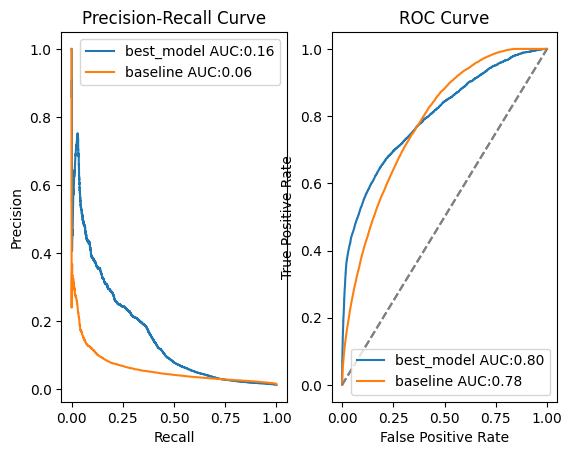

In [57]:
fig, ax = plot_metrics(y_test, y_test_pred[:, 1], model_id="best_model")
plot_metrics(y_test=y_val, y_test_pred=X_val["global_popularity"].values, model_id="baseline", figure=(fig, ax))